## 🧠💡 Intelligent Systems  for Smart Health 👨‍⚕👩‍⚕️🔬🌡️


## Portfolio Exercise 01

# Diabetes prediction

We will again work with data from the NHANES study. But this time we aim to predict something which is a little less dramatic compared to 10-year survival. We want to predict if a patient has **diabetes** or not.

The goal of this portfolio exercise is to complete a full machine learning task from data import to model training an optimization until a final model evaluation.

Good luck!

<a name='import'></a>
## Import Packages

We'll first import all the common packages that we need for this assignment. 

- `shap` is a library that explains predictions made by machine learning models.
- `sklearn` is one of the most popular machine learning libraries.
- `numpy` is a fundamental package for scientific computing in Python.
- `pandas` is what we'll use to manipulate our data.
- `seaborn` is a plotting library which has some convenient functions for visualizing missing data.
- `matplotlib` is a plotting library.

In [2]:
import os
import sklearn
import shap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from skopt import BayesSearchCV

e:\Dokumente\MMI\ISfSH\Repo\Intelligente-Systeme\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Portfolio exercises:
## 1. Load and inspect the data 
- What are missing/problematic entries?

In [5]:
path_root = r'E:\Dokumente\MMI\Datascience\DataScience\is'
data_filename = 'NHANES_2017_2018_diabetes.csv'

df = pd.read_csv(os.path.join(path_root, data_filename))

In [6]:
df.head()

,SEQN,Gender,AgeInYearsAtScreening,HaveSeriousDifficultySeeing,HaveSeriousDifficultyHearing,WeightKg,StandingHeightCm,BodyMassIndexKgm2,BloodMercuryTotalUgl,BloodManganeseUgl,...,TotalSugarsGm_DR1TOT,BloodLeadUgdl,60SecPulse30SecPulse2,DirectHdlcholesterolMgdl,TotalCholesterolMgdl,SystolicBloodPres2NdRdgMmHg,Smoking,PhysicalActivity,diabetes,diabetes_borderline
0,93703.0,1,2.0,0.0,0.0,13.7,88.6,17.5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0
1,93704.0,0,2.0,0.0,0.0,13.9,94.2,15.7,0.47,9.41,...,76.97,NaN,NaN,NaN,NaN,NaN,0,0.0,0,0
2,93705.0,1,66.0,0.0,0.0,79.5,158.3,31.7,1.07,8.57,...,91.55,2.98,52.0,60.0,157.0,NaN,0,1.0,0,0
3,93706.0,0,18.0,0.0,0.0,66.3,175.7,21.5,10.64,14.07,...,14.73,0.74,82.0,47.0,148.0,114.0,0,1.0,0,0
4,93707.0,0,13.0,0.0,0.0,45.4,158.4,18.1,0.20,12.60,...,84.22,0.39,100.0,68.0,189.0,128.0,0,0.0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8366 entries, 0 to 8365
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   SEQN                                     8366 non-null   float64
 1   Gender                                   8366 non-null   int64  
 2   AgeInYearsAtScreening                    8366 non-null   float64
 3   HaveSeriousDifficultySeeing              8365 non-null   float64
 4   HaveSeriousDifficultyHearing             8365 non-null   float64
 5   WeightKg                                 8242 non-null   float64
 6   StandingHeightCm                         8016 non-null   float64
 7   BodyMassIndexKgm2                        8005 non-null   float64
 8   BloodMercuryTotalUgl                     7513 non-null   float64
 9   BloodManganeseUgl                        7513 non-null   float64
 10  BloodSeleniumUgl                         7513 no

Wie Vollständig sind die Zeilen?

In [8]:
print((df.notnull().sum(axis=0)/len(df) * 100).round(2))

SEQN                                       100.00
Gender                                     100.00
AgeInYearsAtScreening                      100.00
HaveSeriousDifficultySeeing                 99.99
HaveSeriousDifficultyHearing                99.99
WeightKg                                    98.52
StandingHeightCm                            95.82
BodyMassIndexKgm2                           95.68
BloodMercuryTotalUgl                        89.80
BloodManganeseUgl                           89.80
BloodSeleniumUgl                            89.80
BloodCadmiumUgl                             89.80
AnnualFamilyIncome                          87.64
AlcoholGm_DR1TOT                            87.08
CholesterolMg_DR1TOT                        87.08
TotalPolyunsaturatedFattyAcidsGm_DR1TOT     87.08
TotalMonounsaturatedFattyAcidsGm_DR1TOT     87.08
TotalSaturatedFattyAcidsGm_DR1TOT           87.08
TotalFatGm_DR1TOT                           87.08
TotalSugarsGm_DR1TOT                        87.08


Wie viel komplette Zeilen gibt es?

In [9]:
len(df.dropna())

4905

-> Sehr viel Informationsverlust

In [10]:
for i in df.columns:
    df_without_i = df.copy()
    df_without_i =  df_without_i.drop(columns=i).dropna(how='any')
    print(f"Menge Daten ohne {i}: {len(df_without_i)}")
    if i != 'diabetes':
        print(sum(df_without_i['diabetes']))

Menge Daten ohne SEQN: 4905
601
Menge Daten ohne Gender: 4905
601
Menge Daten ohne AgeInYearsAtScreening: 4905
601
Menge Daten ohne HaveSeriousDifficultySeeing: 4906
602
Menge Daten ohne HaveSeriousDifficultyHearing: 4905
601
Menge Daten ohne WeightKg: 4905
601
Menge Daten ohne StandingHeightCm: 4905
601
Menge Daten ohne BodyMassIndexKgm2: 4905
601
Menge Daten ohne BloodMercuryTotalUgl: 4905
601
Menge Daten ohne BloodManganeseUgl: 4905
601
Menge Daten ohne BloodSeleniumUgl: 4905
601
Menge Daten ohne BloodCadmiumUgl: 4905
601
Menge Daten ohne AnnualFamilyIncome: 5515
678
Menge Daten ohne AlcoholGm_DR1TOT: 4905
601
Menge Daten ohne CholesterolMg_DR1TOT: 4905
601
Menge Daten ohne TotalPolyunsaturatedFattyAcidsGm_DR1TOT: 4905
601
Menge Daten ohne TotalMonounsaturatedFattyAcidsGm_DR1TOT: 4905
601
Menge Daten ohne TotalSaturatedFattyAcidsGm_DR1TOT: 4905
601
Menge Daten ohne TotalFatGm_DR1TOT: 4905
601
Menge Daten ohne TotalSugarsGm_DR1TOT: 4905
601
Menge Daten ohne BloodLeadUgdl: 4905
601
Me

-> Wenn man bei AnnualFamilyIncome Null Daten füllt würde man 600 Datenpunkte gewinnen. Bei SystolicBloodPres2NdRdgMmHg ~440. Bei beiden würde sich auch die Anzahl an Diabetikern erhöhen.

Gibt es eventuell fehleinträge? Wie sind die Daten verteilt?

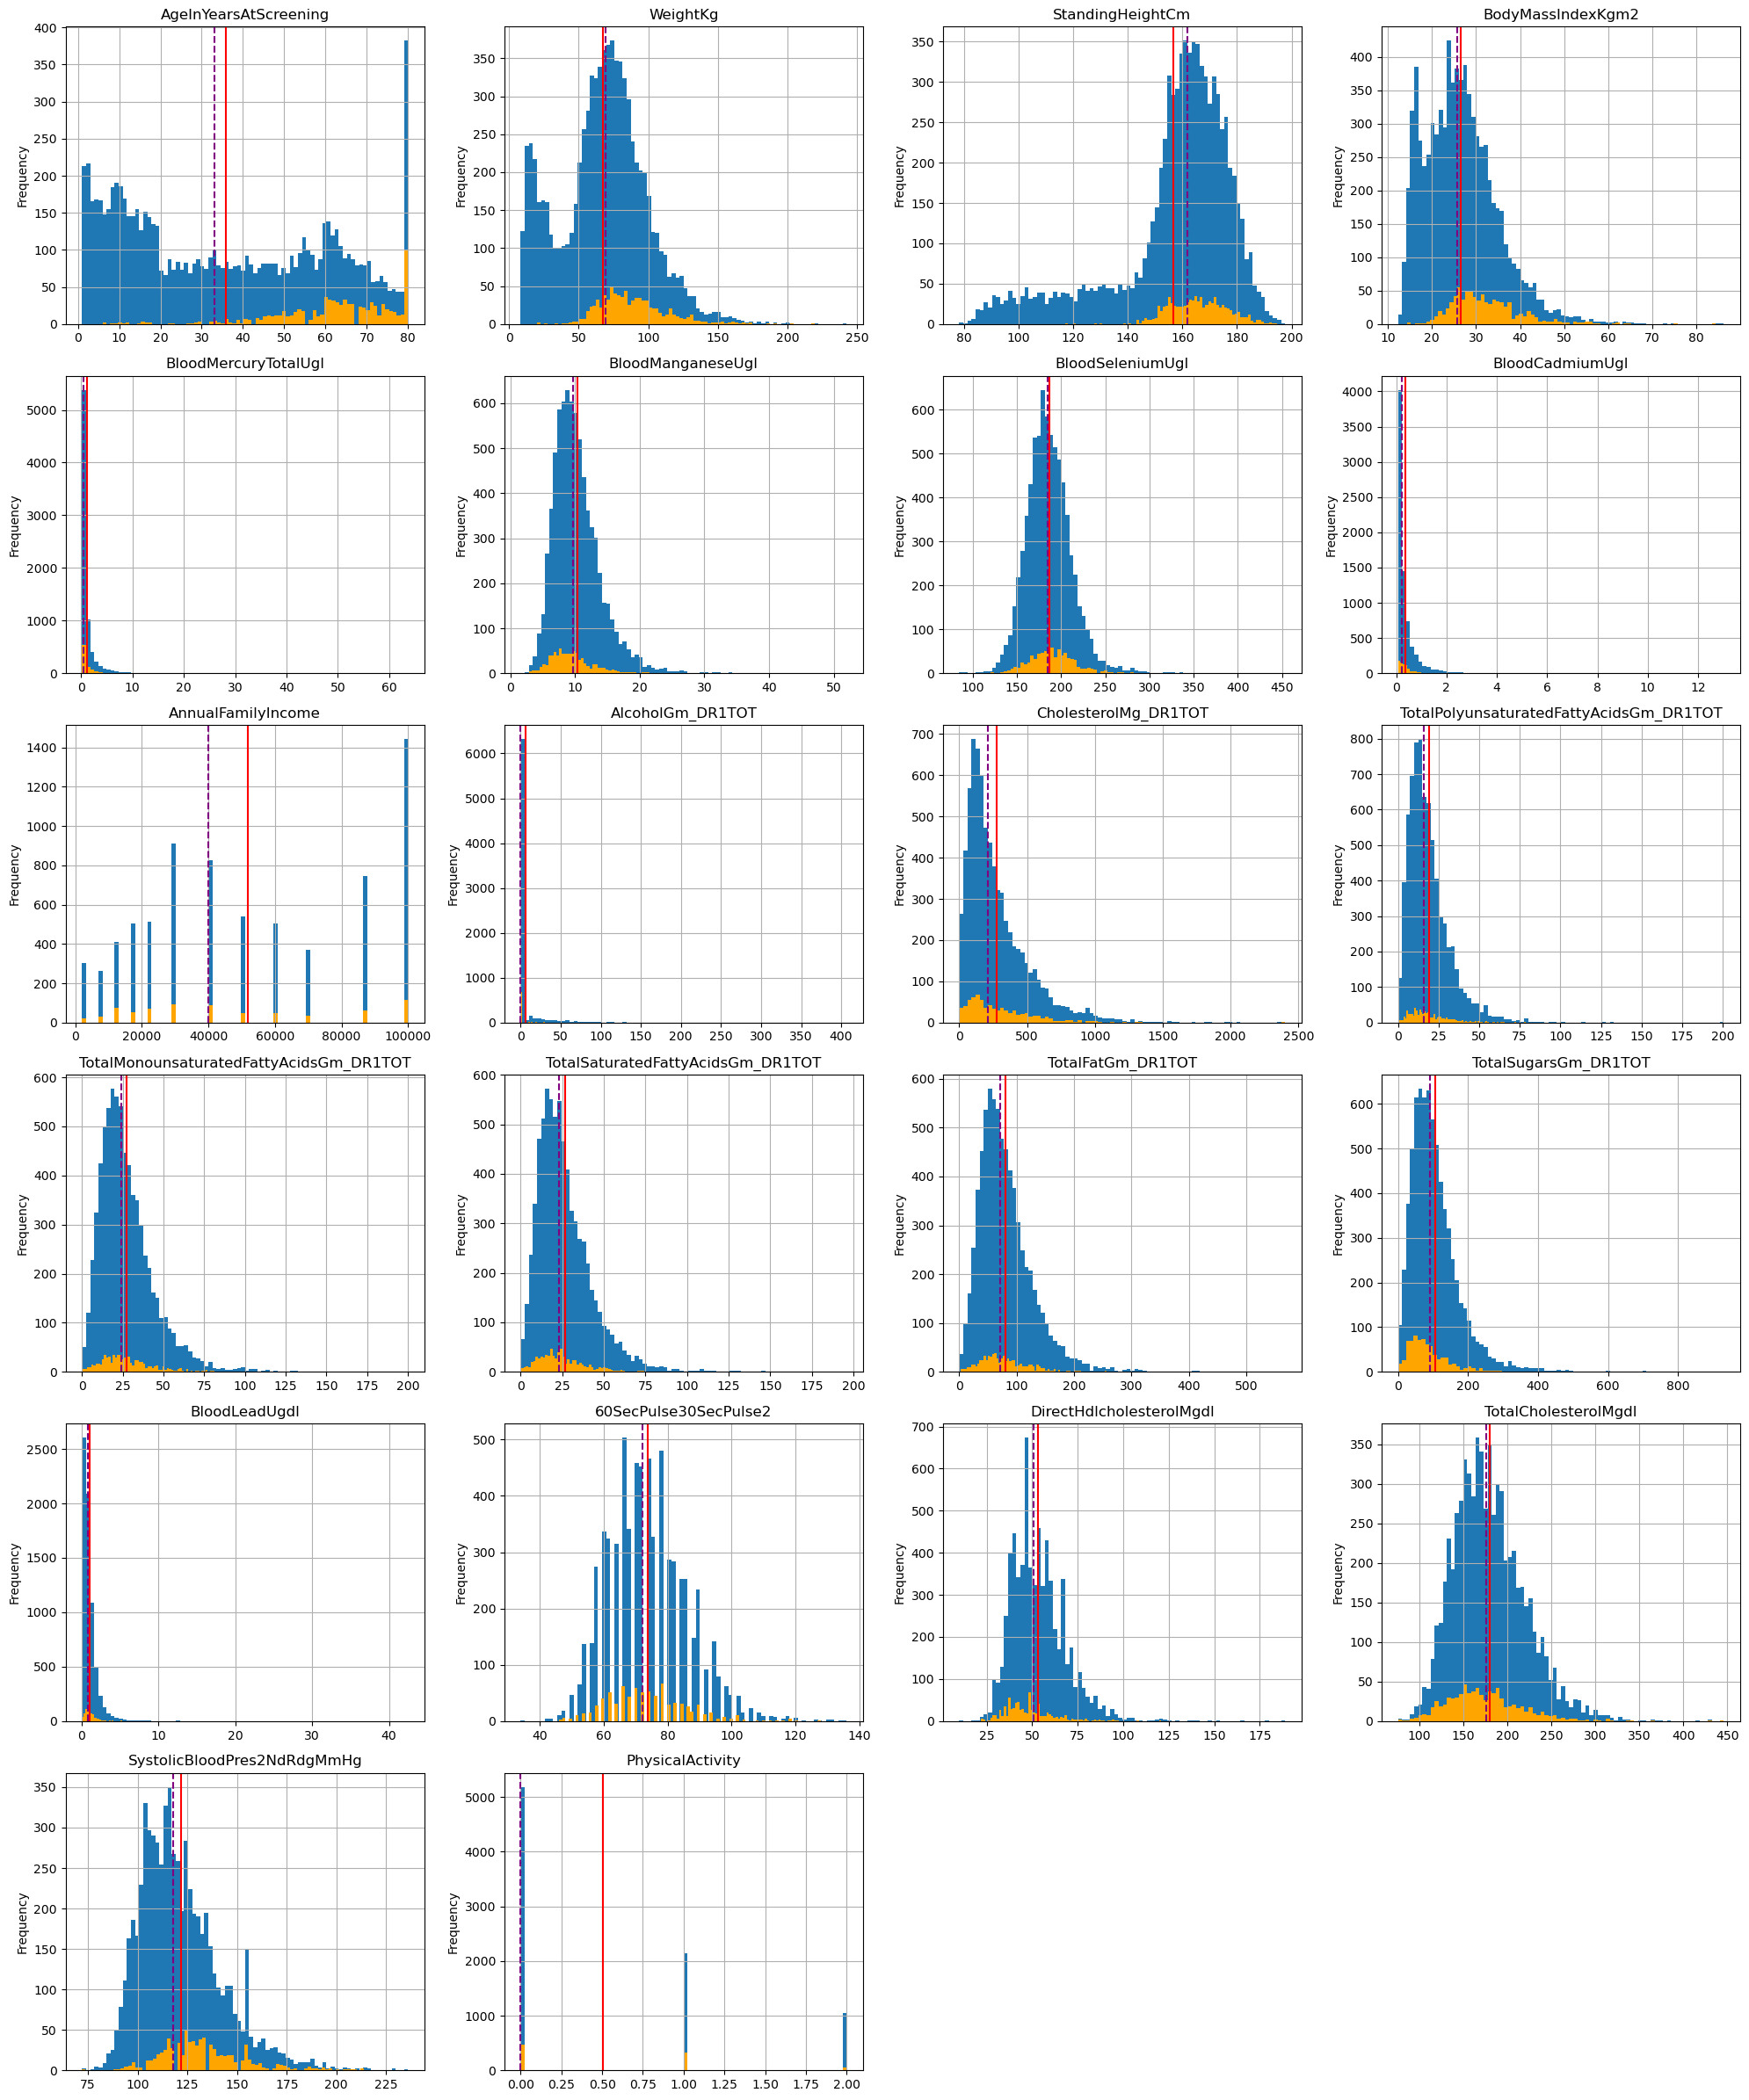

In [11]:
non_binary_cols = [col for col in df.columns if sorted(df[col].dropna().unique()) not in [[0], [1], [0, 1]]]    
non_binary_cols.pop(0)
num_plots = len(non_binary_cols)

cols = 4  
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() 

for idx, col in enumerate(non_binary_cols):
    ax = axes[idx]
    df[col].plot.hist(bins=80, ax=ax)
    df[(df['diabetes']==1)][col].plot.hist(bins=80, ax=ax, color ='orange' )
    ax.axvline(df[col].mean(), color='red')
    ax.axvline(df[col].median(), color='purple', linestyle='--')
    ax.set_title(col)
    ax.grid(True)


for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## 2. Data cleaning 
- Remove, fill, change data (if you think this makes sense or is necessary/beneficial)

Da es sich um eine Medizinische vorhersage handelt bietet die Auffüllung durch interpolierte Werte ein Risiko.

Wenn wir doch durch das füllen von nicht so wichtigen parametern einige neue Diabeteseinträge gewinnen könnte es sich lohnen. Welche Daten könnte man also füllen?
- Bei normalverteilten Daten können gut durch mean gefüllt werden. Bei starker schiefe lieber median.
- Wenn das füllen nichts bzw sehr wenig an bestehenden Korrelationen im Datensatz verändert
- Wenn nicht zu viele Daten fehlen

Alternative: KNN imputer. So kann die Korrelation unter den Daten beachtet werden.

Welche Datenpunkte sind am Schwächsten korreliert?

In [53]:
corr = df.corr()['diabetes']
corr.abs().sort_values(ascending=False)

diabetes                                   1.000000
AgeInYearsAtScreening                      0.360987
BodyMassIndexKgm2                          0.232840
WeightKg                                   0.230927
SystolicBloodPres2NdRdgMmHg                0.208444
HaveSeriousDifficultyHearing               0.178299
HaveSeriousDifficultySeeing                0.140533
StandingHeightCm                           0.139506
DirectHdlcholesterolMgdl                   0.132518
TotalSugarsGm_DR1TOT                       0.082331
BloodManganeseUgl                          0.073057
BloodSeleniumUgl                           0.066484
BloodCadmiumUgl                            0.053696
BloodLeadUgdl                              0.051984
AnnualFamilyIncome                         0.049428
diabetes_borderline                        0.049251
TotalCholesterolMgdl                       0.048411
BloodMercuryTotalUgl                       0.041041
Gender                                     0.038384
CholesterolM

Daten unter 0.1 können ohne ein großes Risiko von einem KNN imputer erzeugt werden.

Smoking, PhysicalActivity, Gender sind bereits voll.

AnnualFamilyIncome hat keinen direkten Zusammenhang mit den anderen Medizienischen Werten -> füllen durch Median.

#### KNN imputer

In [47]:
colums_to_impute = ['60SecPulse30SecPulse2',
                    'TotalPolyunsaturatedFattyAcidsGm_DR1TOT',
                    'TotalMonounsaturatedFattyAcidsGm_DR1TOT',
                    'TotalFatGm_DR1TOT',
                    'AlcoholGm_DR1TOT',
                    'TotalSaturatedFattyAcidsGm_DR1TOT',
                    'CholesterolMg_DR1TOT',
                    'BloodMercuryTotalUgl',
                    'TotalCholesterolMgdl',
                    'BloodLeadUgdl',
                    'BloodCadmiumUgl',
                    'BloodSeleniumUgl',
                    'BloodManganeseUgl',
                    'TotalSugarsGm_DR1TOT']


imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df[colums_to_impute]), columns=colums_to_impute)

df_imputed_full = df.copy()
df_imputed_full[colums_to_impute] = df_imputed

In [48]:
df_imputed_full['AnnualFamilyIncome'] = df['AnnualFamilyIncome'].fillna(df['AnnualFamilyIncome'].median())

Später können die Imputierten Daten mit den Daten, wo alles gedropped wurde verglichen werden.

Keine Daten müssen umformatiert werden

In [49]:
cleaned_data = df.dropna()
cleaned_imputed_data = df_imputed_full.dropna()

In [50]:
cleaned_data.value_counts(['diabetes','diabetes_borderline'])

diabetes  diabetes_borderline
0         0                      4179
1         0                       601
0         1                       125
Name: count, dtype: int64

**'Diabetes'** und **'Diabetes_borderline'** sind exklusiv. Da wir Diabetes vorhersagen wollen sollten wir die **'Diabetes_borderline'** spalte entfernen. Sonst lernt das Model: 1 in Diabetes_borderline = Kein Diabetes.

In [51]:
cleaned_data = cleaned_data.drop(columns='diabetes_borderline')
cleaned_imputed_data = cleaned_imputed_data.drop(columns='diabetes_borderline')

**'SEQN'** ist lediglich eine ID spalte und kann auch entfernt werden

In [52]:
cleaned_data = cleaned_data.drop(columns='SEQN')
cleaned_imputed_data = cleaned_imputed_data.drop(columns='SEQN')

## 3. Inspect correlations among the features 
- Which features do you expect to play a role for a later machine learning model (for predicting diabetes), and why?


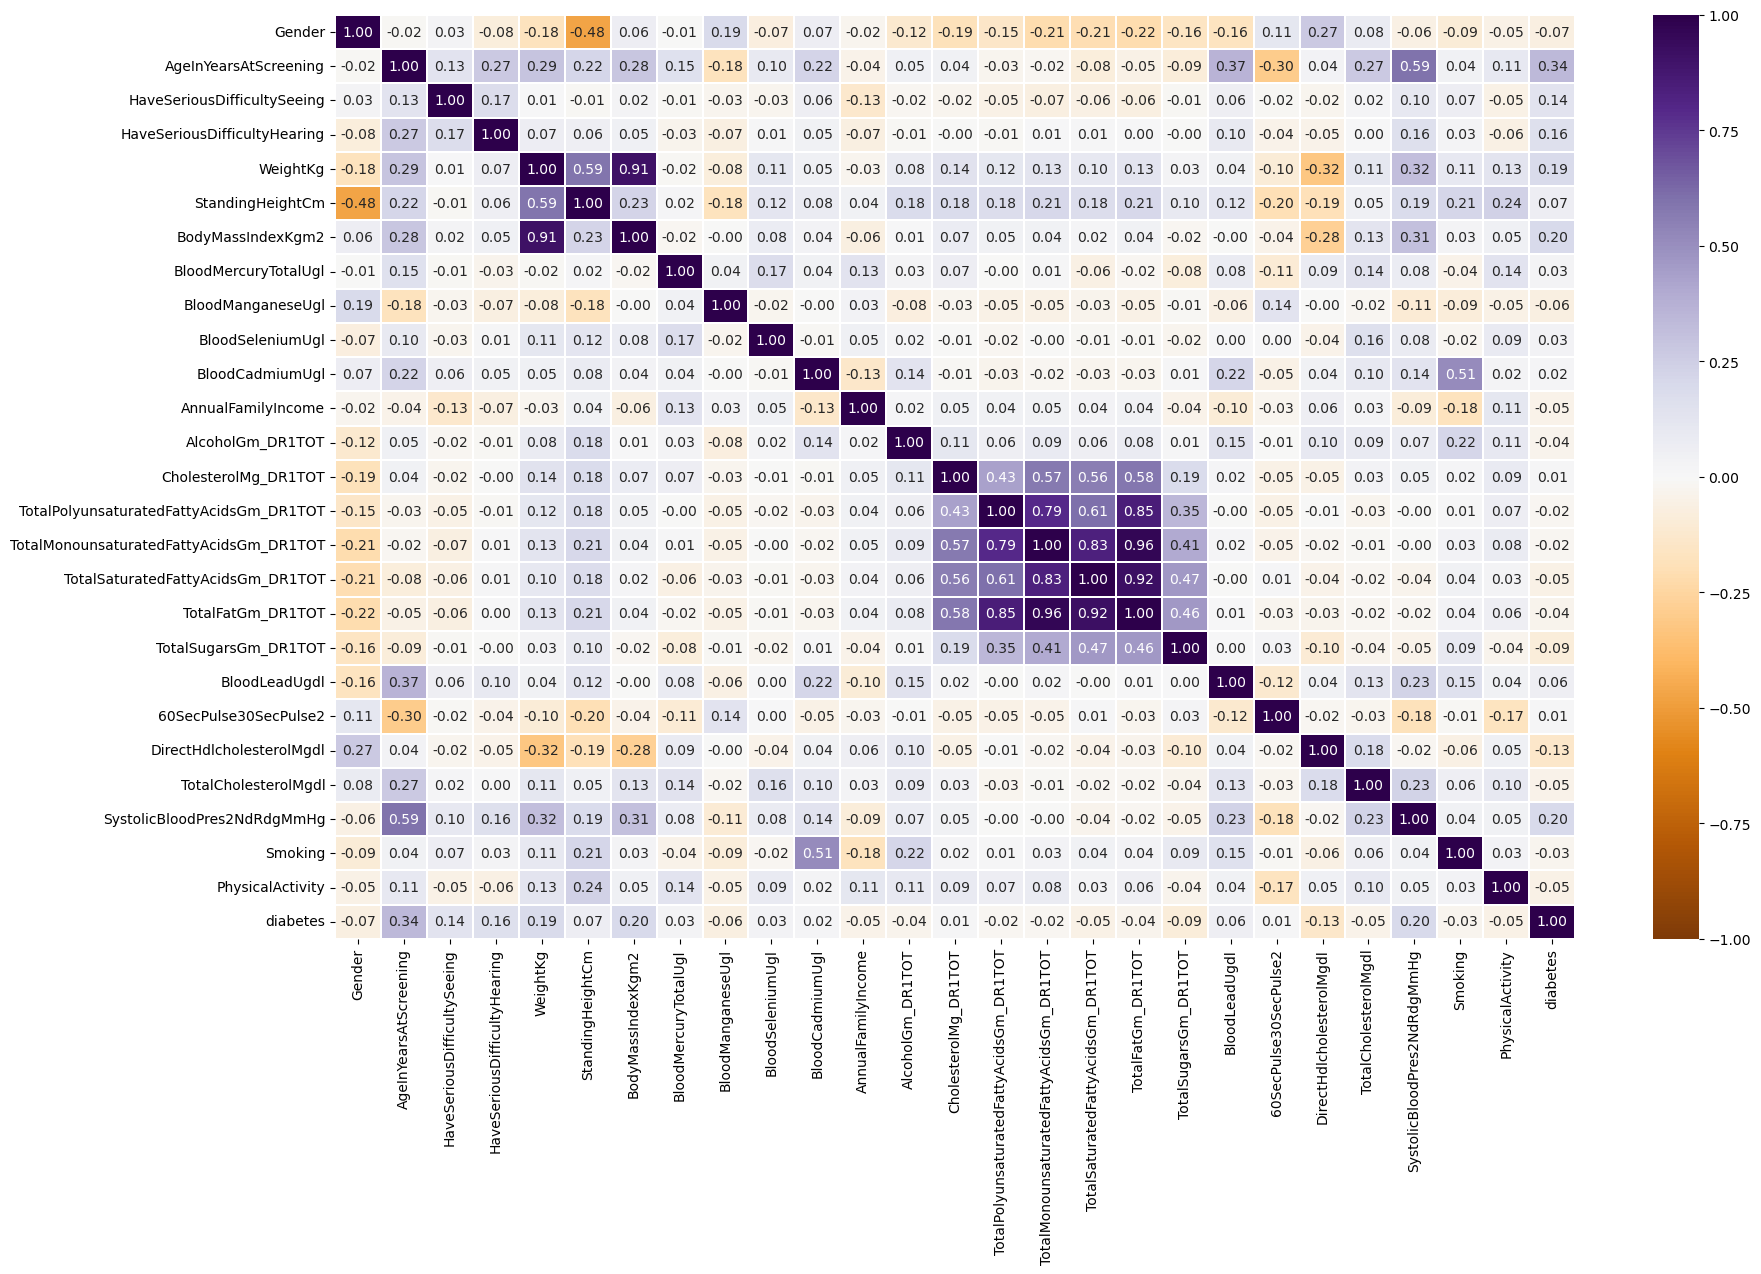

In [20]:
plt.figure(figsize=(20, 12))
matrix = sns.heatmap(cleaned_data.corr(),annot=True,linewidths=0.1,vmax=1,vmin=-1,fmt=".2f", cmap= 'PuOr')

Wie sieht die Korrelation der imputierten Daten im Vergleich aus?

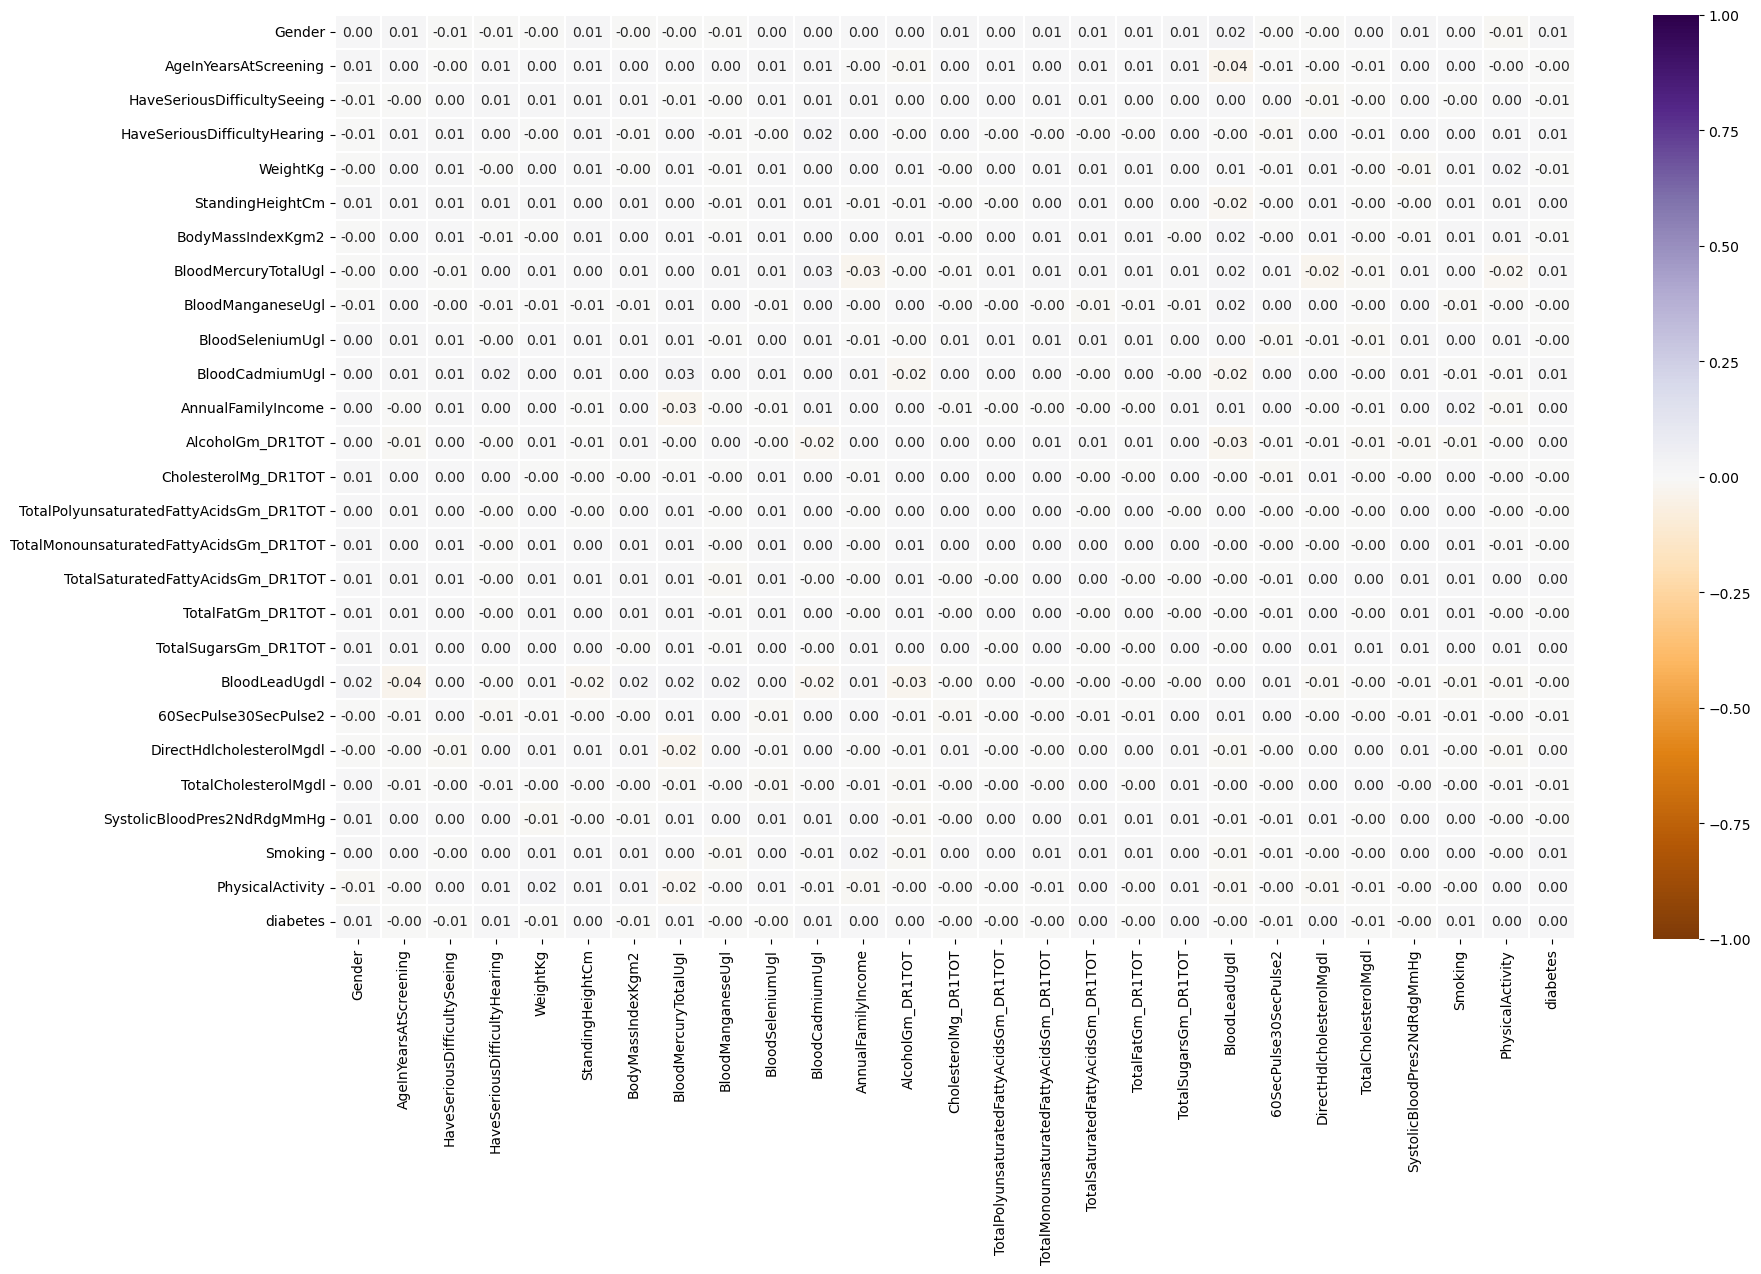

In [21]:
plt.figure(figsize=(20, 12))
matrix = sns.heatmap(cleaned_imputed_data.corr()-cleaned_data.corr(),annot=True,linewidths=0.1,vmax=1,vmin=-1,fmt=".2f", cmap= 'PuOr')

-> Kein nennenswerter Unterschied vorhanden

**'BodyMassIndexKgm2'** mit **'WeightKg'** sowie **'TotalFatGm_DR1TOT'** mit **'TotalMonounsaturatedFattyAcidsGm_DR1TOT'** und **'TotalSaturatedFattyAcidsGm_DR1TOT'** sind untereinander stark korreliert (corr<0.9) und können reduziert werden. 

Die Wahl fällt hierbei auf BMI und TotalFatGm_DR1TOT.

In [22]:
cleaned_data = cleaned_data.drop(columns=['BodyMassIndexKgm2','TotalFatGm_DR1TOT'])
cleaned_imputed_data = cleaned_imputed_data.drop(columns=['BodyMassIndexKgm2','TotalFatGm_DR1TOT'])

In [23]:
corr = cleaned_data.corr()['diabetes']
corr.abs().nlargest(10)

diabetes                        1.000000
AgeInYearsAtScreening           0.339323
SystolicBloodPres2NdRdgMmHg     0.202029
WeightKg                        0.194029
HaveSeriousDifficultyHearing    0.160687
HaveSeriousDifficultySeeing     0.135759
DirectHdlcholesterolMgdl        0.133994
TotalSugarsGm_DR1TOT            0.088942
StandingHeightCm                0.068194
Gender                          0.066186
Name: diabetes, dtype: float64

In [24]:
corr2 = cleaned_imputed_data.corr()['diabetes']
(((corr2.abs()).sort_index(ascending=True))- (corr.abs().sort_index(ascending=True))).nlargest(10)

BloodCadmiumUgl                            0.012496
HaveSeriousDifficultyHearing               0.006525
TotalCholesterolMgdl                       0.006101
BloodMercuryTotalUgl                       0.005455
TotalPolyunsaturatedFattyAcidsGm_DR1TOT    0.003949
BloodManganeseUgl                          0.002937
TotalMonounsaturatedFattyAcidsGm_DR1TOT    0.002220
StandingHeightCm                           0.000180
diabetes                                   0.000000
CholesterolMg_DR1TOT                      -0.000448
Name: diabetes, dtype: float64

An der Korrelationsspalte für Diabetes sieht man welche Messwerte eine größere Rolle in der späteren Einordnung führen könnten. Dies schließt schwach Korrelierte werte jedoch nicht aus!

Zu diesen Messwerten gehören:
 - AgeInYearsAtScreening           
 - SystolicBloodPres2NdRdgMmHg
 - WeightKg
 - HaveSeriousDifficultyHearing
 - HaveSeriousDifficultySeeing
 - DirectHdlcholesterolMgdl               

Auch für den Imputierten Datensatz sind die Werte sehr ähnlich.

In [25]:
non_binary_cols = [col for col in cleaned_data.columns if sorted(cleaned_data[col].dropna().unique()) not in [[0], [1], [0, 1]]]

Ein pairplot mit nichtbinären Daten soll dazu dienen Zusammenhänge zu erkennen die nicht direkt anhand der Korrelationsmatrix erkennbar sind.'

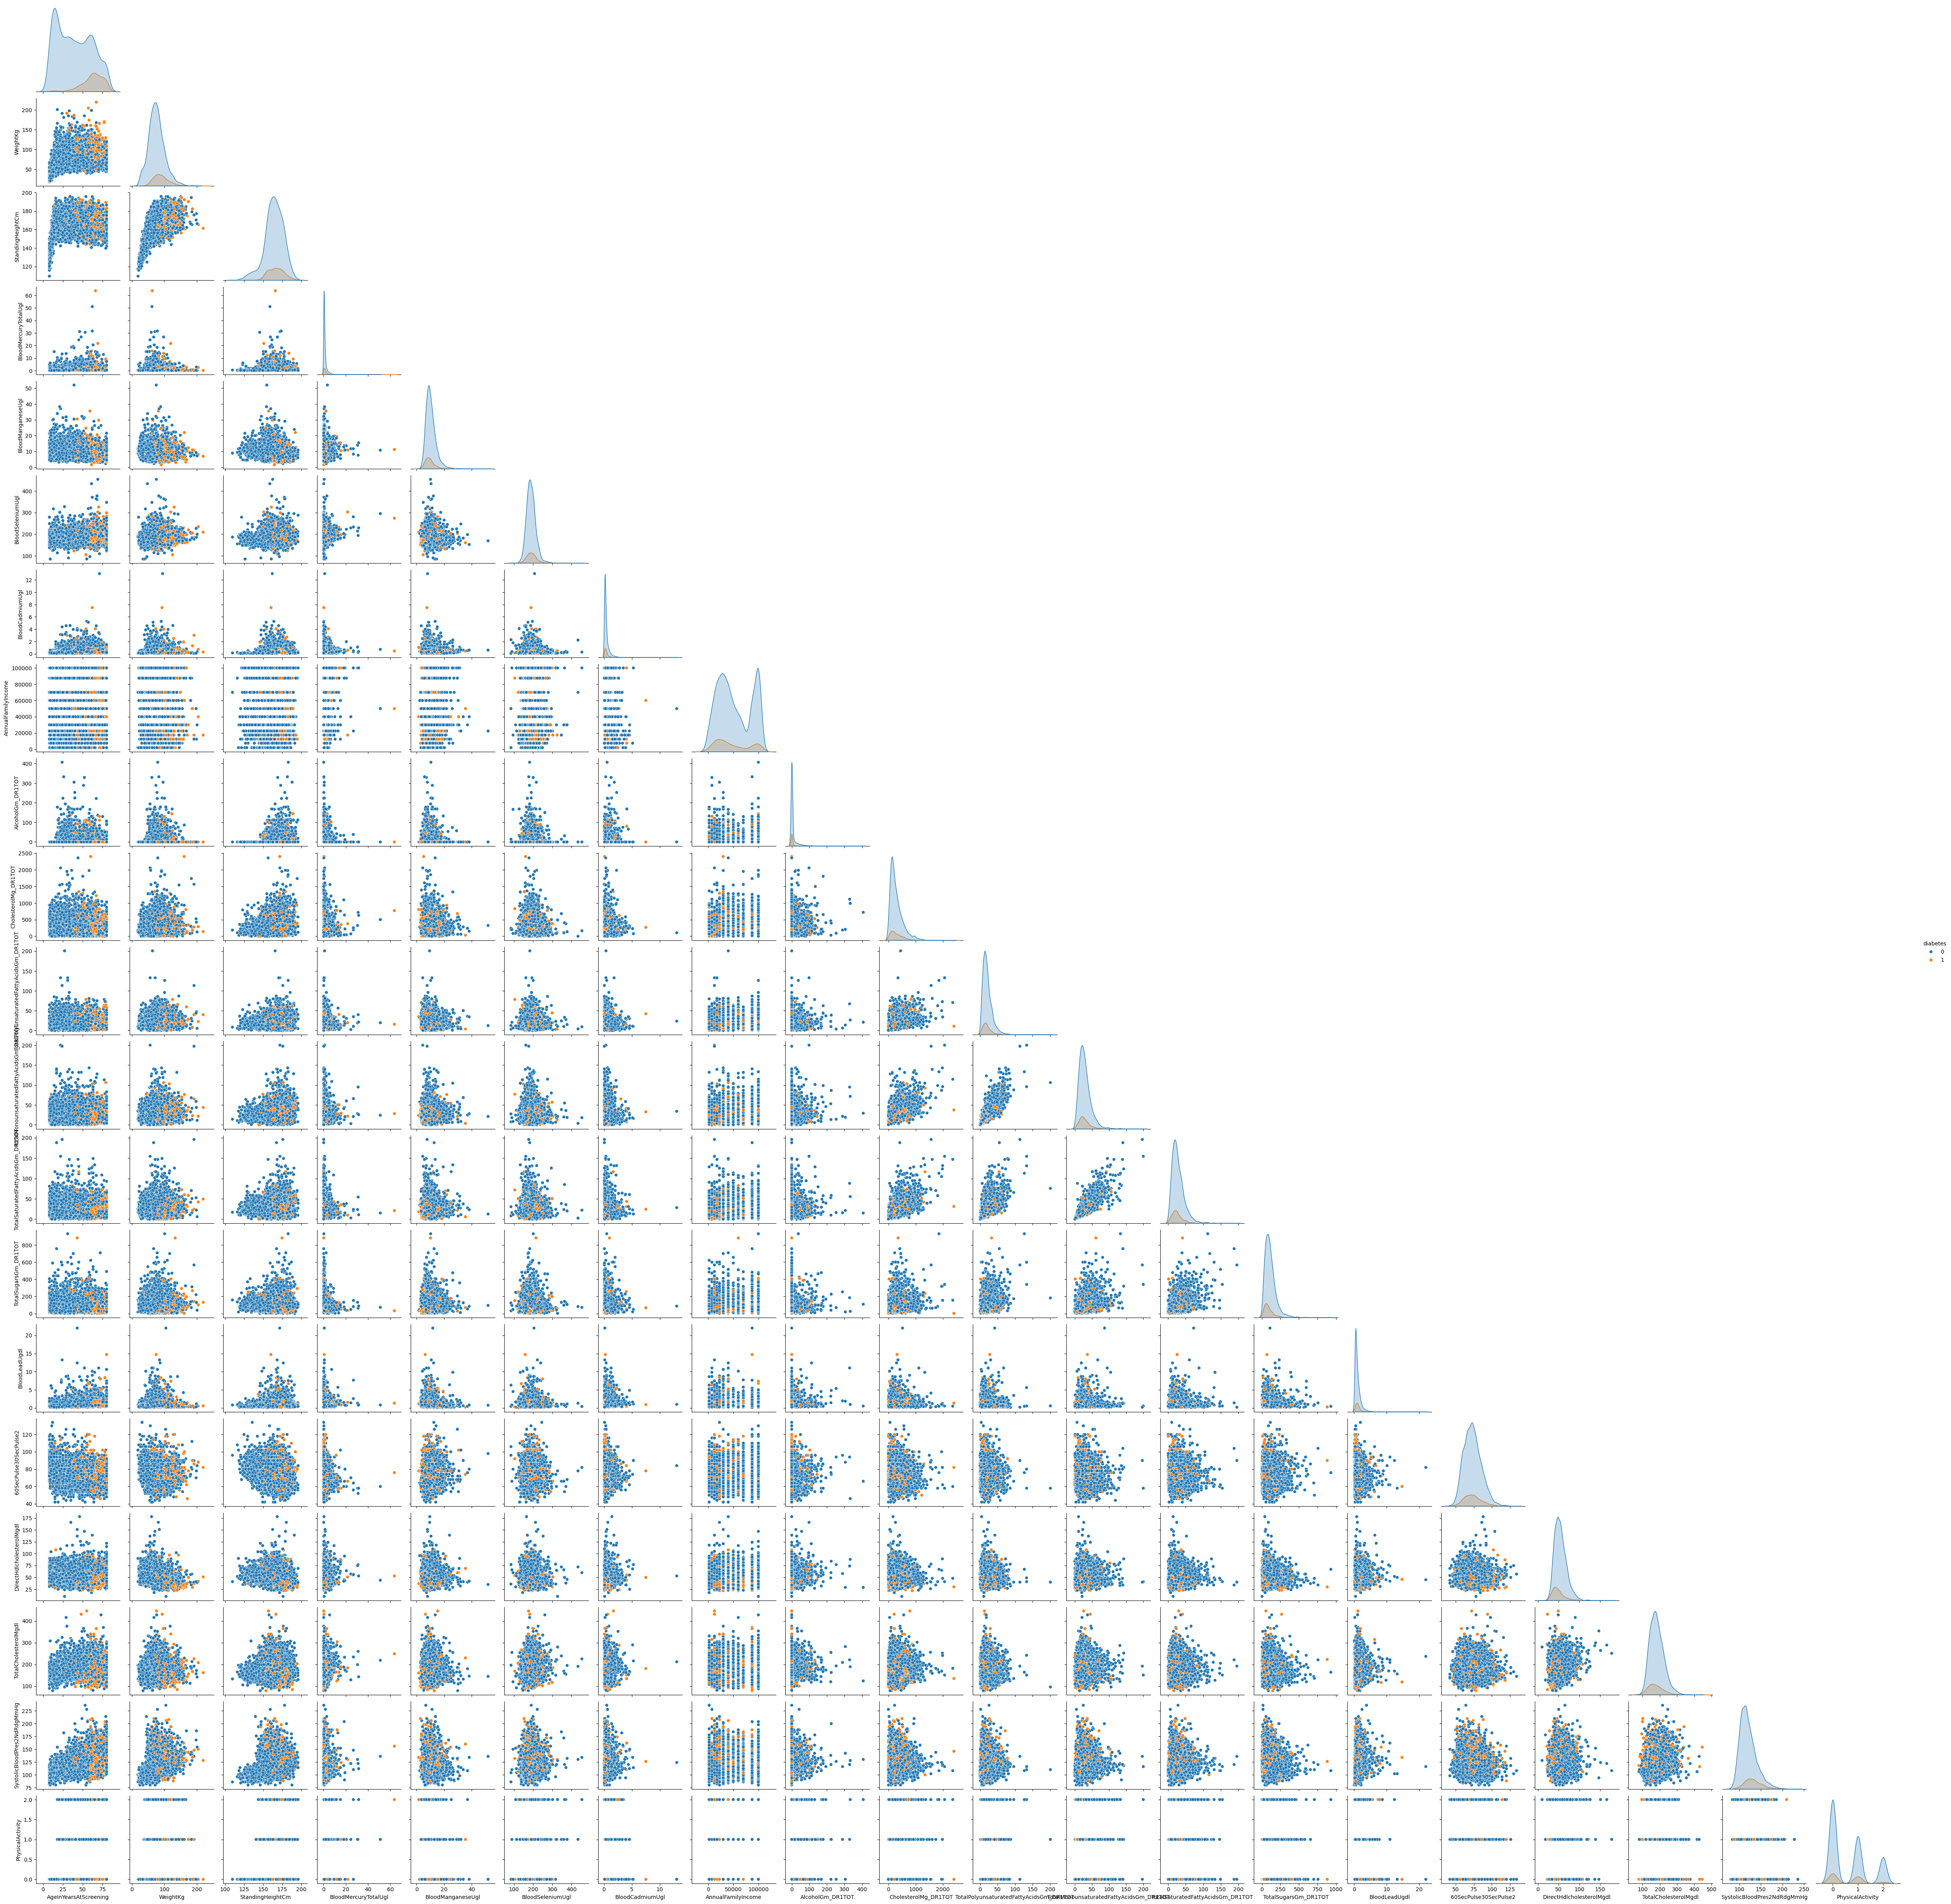

In [23]:
sns.pairplot(data=cleaned_data,hue='diabetes', corner=True, vars=non_binary_cols)

## 4. Prepare data for machine learning: 
- Separate data and labels
- Split into train ~70% / validation ~15% / test ~15%


In [26]:
X = cleaned_data.drop(['diabetes'], axis='columns')
y = cleaned_data['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=10)

X_test, X_val, y_test, y_val = train_test_split(X_test, y_test,
                                                  test_size=0.5, random_state=10)

In [27]:
X_train.shape, X_val.shape, X_test.shape

((3433, 24), (736, 24), (736, 24))

Das model mit den Imputed Daten soll nicht auf basis dieser geschätzten Werte evaluiert werden und wird deshalb die selben Validierungsdaten von 'cleaned_data' verwenden. Die test und val Daten müssen jedoch aus den imputierten Daten raus genommen werden, da diese sonst gelernt werden.

In [28]:
mask_test = cleaned_imputed_data.drop(['diabetes'], axis='columns').apply(lambda row: row.values.tolist() in X_test.values.tolist(), axis=1)
mask_val = cleaned_imputed_data.drop(['diabetes'], axis='columns').apply(lambda row: row.values.tolist() in X_val.values.tolist(), axis=1)

Sind die Masken korrekt?

In [29]:
print(sum(mask_test))
print(sum(mask_val))

736
736


In [30]:
mask = mask_test|mask_val
print(sum(mask))

1472


In [31]:
cleaned_imputed_data_test_val_removed = cleaned_imputed_data[~mask]

In [32]:
X_train_imp = cleaned_imputed_data_test_val_removed.drop(['diabetes'], axis='columns')
y_train_imp   = cleaned_imputed_data_test_val_removed['diabetes']

Da beide Datensätze den selben Test und Validation Datensatz benutzen, ist die Anteilverteilung bei den Imputierten Daten (70%, 15%, 15%) nicht korrekt.

## 5. Train a first model (random forest)
- Use validation and training set to avoid overfitting
- Optimize your hyperparameters with a simple grid search
- Evaluate the model using accuracy, confusion matrix, F1-score, and ROC curve
- How good is the model? What are the main problems?


In [38]:
from sklearn.model_selection import GridSearchCV
import sklearn.metrics

def plot_confusion_matrix(confusion_matrix):
    """ Simple plot of a confusion matrix using Seaborn's heatmap."""
    plt.figure(figsize=(6, 4), dpi=100)
    sns.heatmap(confusion_matrix, annot=True, annot_kws={"size": 16},
                cmap="Purples",
                fmt="g")

    # Set labels and title
    plt.xlabel('Predicted', fontsize=16)
    plt.ylabel('Actual', fontsize=16)
    plt.title('Confusion Matrix', fontsize=20)

def plot_roc_curve(labels, predicted_labels, dpi=300):
    """
    Plots the Receiver Operating Characteristic (ROC) curve.

    Parameters:
    labels (array-like): True binary labels.
    predicted_labels (array-like): Target scores, can either be probability estimates 
                                   of the positive class or confidence values.

    This function calculates the false positive rate (FPR) and true positive rate (TPR)
    to plot the ROC curve. It also computes the Area Under the Curve (AUC) to assess 
    the performance of the model.

    Example:
        plot_roc_curve(y_true, y_scores)

    """
    # Calculate the false positive rate (FPR) and true positive rate (TPR)
    fpr, tpr, _ = sklearn.metrics.roc_curve(labels, predicted_labels)

    # Calculate the AUC (Area Under the Curve)
    roc_auc = sklearn.metrics.auc(fpr, tpr)

    # Plot the ROC curve
    fig, ax = plt.subplots(figsize=(8, 8), dpi=dpi)
    ax.plot(fpr, tpr, color='cornflowerblue', lw=2, 
            label=f'ROC curve (AUC = {roc_auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random chance')  # Diagonal line
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.0])
    ax.set_xlabel('False Positive Rate', fontsize=16)
    ax.set_ylabel('True Positive Rate', fontsize=16)
    ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=18)
    ax.legend(loc="lower right", fontsize=14)
    ax.grid(True)

    # Show the plot
    plt.show()

### Full Drop Data Model

In [32]:
param_grid = {
    'n_estimators': [100, 200, 300],          
    'max_depth': [10, 20, 30],                
    'min_samples_leaf': [1, 2, 4],            
}

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

forest =RandomForestClassifier(random_state=0)
grid_search = GridSearchCV(estimator=forest,
                           param_grid=param_grid,
                           cv=5,                     
                           n_jobs=-1,                
                           verbose=1,
                           scoring=scoring,
                           refit='f1')

In [33]:
grid_search.fit(X_train, y_train)

print(f'Beste Parameter: {grid_search.best_params_}, Score: {grid_search.best_score_}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Beste Parameter: {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 100}, Score: 0.18970255115123777


accuracy_score: 0.8845108695652174
f1_score: 0.17475728155339806
recall_score: 0.0989010989010989
precision_score: 0.75
ROC AOC: 0.8404123008774171
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       645
           1       0.75      0.10      0.17        91

    accuracy                           0.88       736
   macro avg       0.82      0.55      0.56       736
weighted avg       0.87      0.88      0.84       736



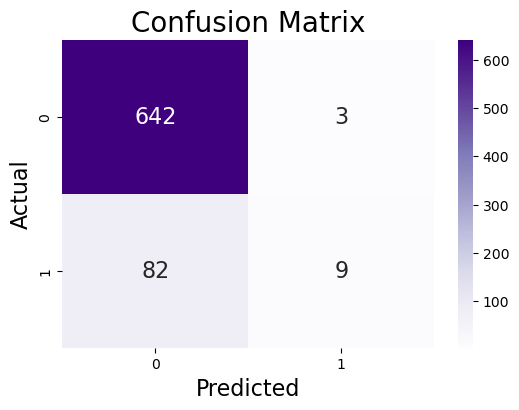

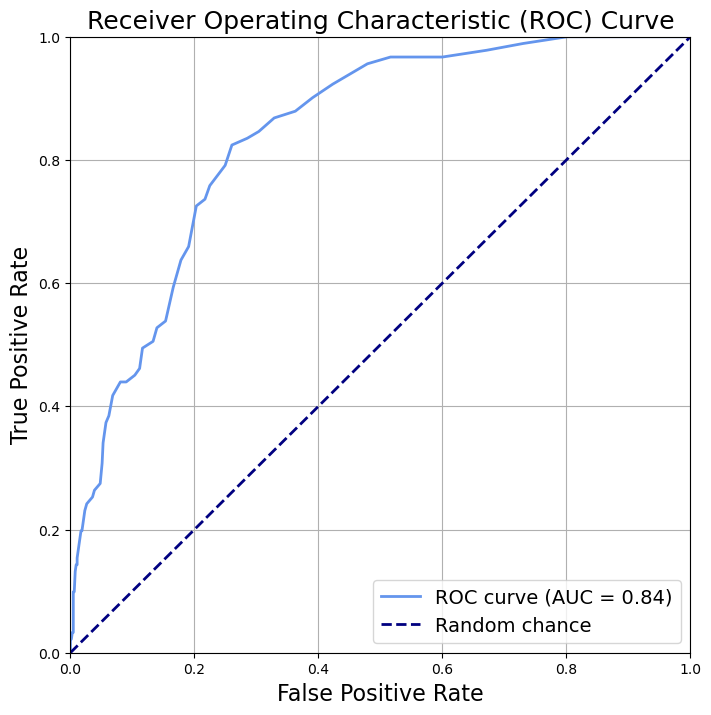

In [34]:
y_val_preds = grid_search.predict(X_val)
y_val_preds_proba = grid_search.predict_proba(X_val)[:, 1]
conf_matrix = sklearn.metrics.confusion_matrix(y_val, y_val_preds)
plot_confusion_matrix(conf_matrix)
print(f'accuracy_score: {sklearn.metrics.accuracy_score(y_val, y_val_preds)}')
print(f'f1_score: {sklearn.metrics.f1_score(y_val, y_val_preds)}')
print(f'recall_score: {sklearn.metrics.recall_score(y_val, y_val_preds)}')
print(f'precision_score: {sklearn.metrics.precision_score(y_val, y_val_preds)}')
print(f'ROC AOC: {sklearn.metrics.roc_auc_score(y_val, y_val_preds_proba)}')
print(sklearn.metrics.classification_report(y_val, y_val_preds))
plot_roc_curve(y_val,y_val_preds_proba, dpi=100)

### Imputed Data Model

In [35]:
param_grid = {
    'n_estimators': [100, 200, 300],          
    'max_depth': [10, 20, 30],                
    'min_samples_leaf': [1, 2, 4],            
}

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

forest_imp =RandomForestClassifier(random_state=0)
grid_search_imp = GridSearchCV(estimator=forest_imp,
                           param_grid=param_grid,
                           cv=5,                     
                           n_jobs=-1,                
                           verbose=1,
                           scoring=scoring,
                           refit='f1')

In [36]:
grid_search_imp.fit(X_train_imp, y_train_imp)

print(f'Beste Parameter: {grid_search_imp.best_params_}, Score: {grid_search_imp.best_score_}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Beste Parameter: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 100}, Score: 0.1617483507273156


accuracy_score: 0.8831521739130435
f1_score: 0.17307692307692307
recall_score: 0.0989010989010989
precision_score: 0.6923076923076923
ROC AOC: 0.8343726041400459
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       645
           1       0.69      0.10      0.17        91

    accuracy                           0.88       736
   macro avg       0.79      0.55      0.56       736
weighted avg       0.86      0.88      0.84       736



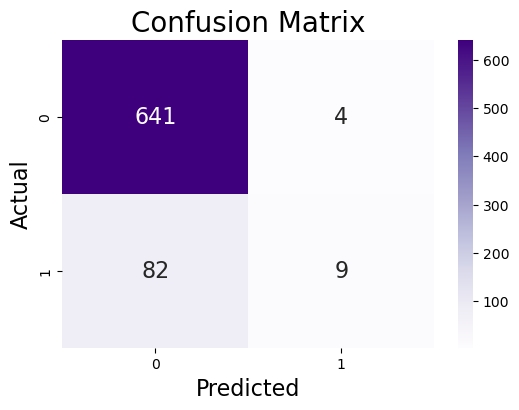

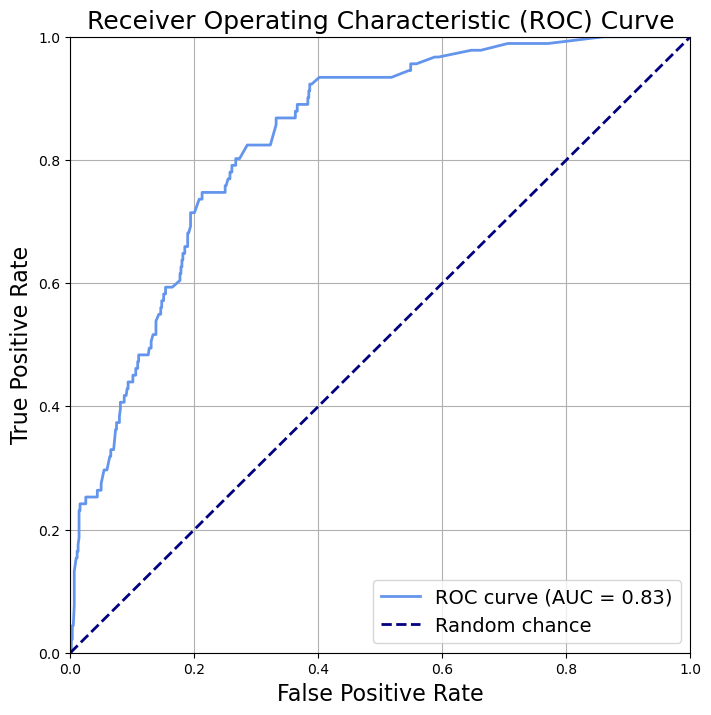

In [37]:
y_val_imp_preds = grid_search_imp.predict(X_val)
y_val_imp_preds_proba = grid_search_imp.predict_proba(X_val)[:, 1]
conf_matrix = sklearn.metrics.confusion_matrix(y_val, y_val_imp_preds)
plot_confusion_matrix(conf_matrix)
print(f'accuracy_score: {sklearn.metrics.accuracy_score(y_val, y_val_imp_preds)}')
print(f'f1_score: {sklearn.metrics.f1_score(y_val, y_val_imp_preds)}')
print(f'recall_score: {sklearn.metrics.recall_score(y_val, y_val_imp_preds)}')
print(f'precision_score: {sklearn.metrics.precision_score(y_val, y_val_imp_preds)}')
print(f'ROC AOC: {sklearn.metrics.roc_auc_score(y_val, y_val_imp_preds_proba)}')
print(sklearn.metrics.classification_report(y_val, y_val_imp_preds))
plot_roc_curve(y_val,y_val_imp_preds_proba, dpi=100)

## 6. Check if labels are balanced
- If the data is not balanced enough, try to mitigate this problem (e.g. by oversampling or adding class weights).
- Use any hyperparameter search strategy you know (grid search, random search, or Bayesian search)
- Use the same evaluation metrics as above to inspect the quality of your model.


How Imbalanced is the Dataset?

In [38]:
cleaned_data['diabetes'].value_counts()

diabetes
0    4304
1     601
Name: count, dtype: int64

In [39]:
cleaned_imputed_data['diabetes'].value_counts()

diabetes
0    5225
1     738
Name: count, dtype: int64

In [40]:
print(cleaned_data['diabetes'].sum()/ len(cleaned_data['diabetes']))
print(cleaned_imputed_data['diabetes'].sum() / len(cleaned_imputed_data['diabetes']))

0.12252803261977574
0.12376320643971156


Beide versionen der Datensätze haben eine starke inbalance. 

### Full Drop Model

In [ ]:
param_distributions = {
    'n_estimators': (100, 500),         
    'max_depth': (5, 50),                 
    'min_samples_split': (2, 20),         
    'min_samples_leaf': (1, 10),
}

random_forest = RandomForestClassifier(random_state=0, class_weight='balanced')

bayes_search = BayesSearchCV(
    estimator=random_forest,
    search_spaces= param_distributions,
    n_iter=6,       
    cv=5,
    random_state=0,
    scoring='f1'
)

In [42]:
bayes_search.fit(X_train, y_train)

print(f'Beste Parameter: {bayes_search.best_params_}, Score: {bayes_search.best_score_}')

Beste Parameter: OrderedDict([('max_depth', 17), ('min_samples_leaf', 10), ('min_samples_split', 18), ('n_estimators', 340)]), Score: 0.48211667199958796


accuracy_score: 0.8383152173913043
f1_score: 0.43601895734597157
recall_score: 0.5054945054945055
precision_score: 0.38333333333333336
ROC AOC: 0.8538887469120027
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       645
           1       0.38      0.51      0.44        91

    accuracy                           0.84       736
   macro avg       0.66      0.70      0.67       736
weighted avg       0.86      0.84      0.85       736



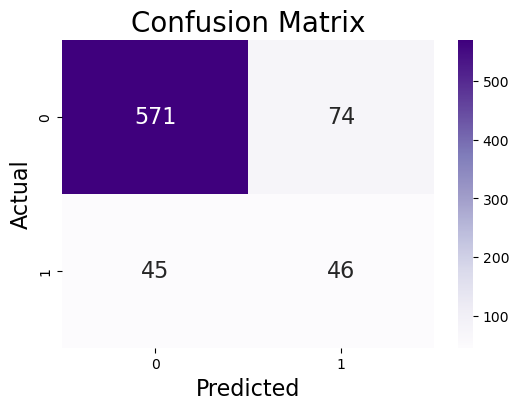

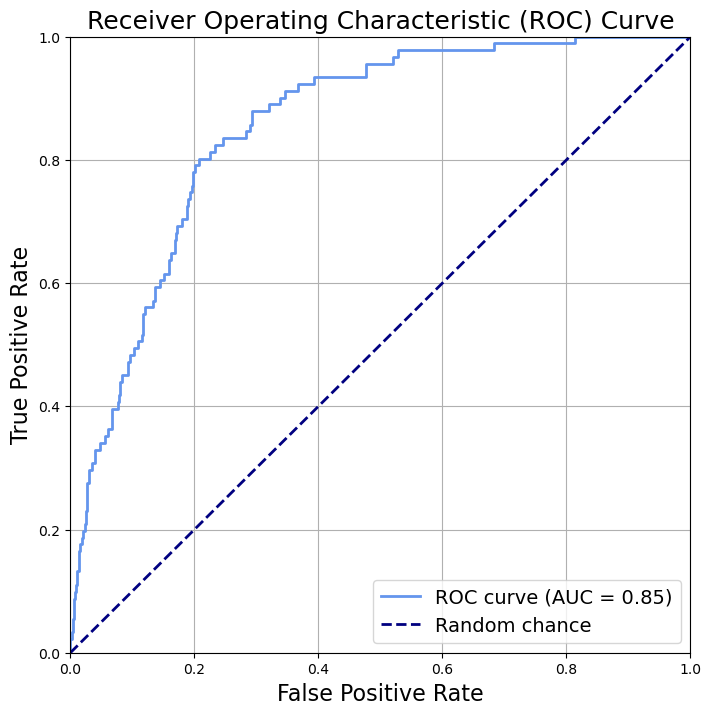

In [43]:
y_val_preds = bayes_search.predict(X_val)
y_val_preds_proba = bayes_search.predict_proba(X_val)[:, 1]
conf_matrix = sklearn.metrics.confusion_matrix(y_val, y_val_preds)
plot_confusion_matrix(conf_matrix)
print(f'accuracy_score: {sklearn.metrics.accuracy_score(y_val, y_val_preds)}')
print(f'f1_score: {sklearn.metrics.f1_score(y_val, y_val_preds)}')
print(f'recall_score: {sklearn.metrics.recall_score(y_val, y_val_preds)}')
print(f'precision_score: {sklearn.metrics.precision_score(y_val, y_val_preds)}')
print(f'ROC AOC: {sklearn.metrics.roc_auc_score(y_val, y_val_preds_proba)}')
print(sklearn.metrics.classification_report(y_val, y_val_preds))
plot_roc_curve(y_val,y_val_preds_proba, dpi=100)

### Imputed Data Model

In [43]:
param_distributions = {
    'n_estimators': (100, 500),         
    'max_depth': (5, 50),                 
    'min_samples_split': (2, 20),         
    'min_samples_leaf': (1, 10),
}

random_forest_imp = RandomForestClassifier(random_state=0, class_weight='balanced')

bayes_search_imp = BayesSearchCV(
    estimator=random_forest_imp,
    search_spaces= param_distributions,
    n_iter=6,       
    cv=5,
    random_state=0,
    scoring='f1'
)

In [44]:
bayes_search_imp.fit(X_train_imp, y_train_imp)

print(f'Beste Parameter: {bayes_search_imp.best_params_}, Score: {bayes_search_imp.best_score_}')

Beste Parameter: OrderedDict([('max_depth', 17), ('min_samples_leaf', 10), ('min_samples_split', 18), ('n_estimators', 340)]), Score: 0.4605314725104848


accuracy_score: 0.8505434782608695
f1_score: 0.47115384615384615
recall_score: 0.5384615384615384
precision_score: 0.4188034188034188
ROC AOC: 0.8559672885254281
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       645
           1       0.42      0.54      0.47        91

    accuracy                           0.85       736
   macro avg       0.68      0.72      0.69       736
weighted avg       0.87      0.85      0.86       736



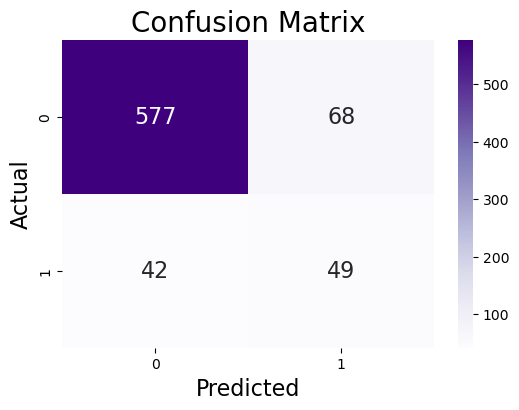

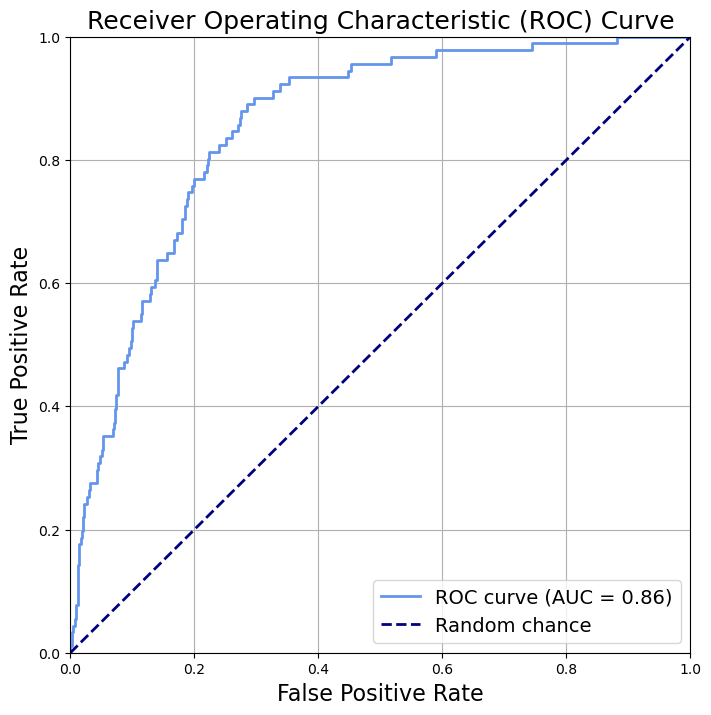

In [45]:
y_val_preds = bayes_search_imp.predict(X_val)
y_val_preds_proba = bayes_search_imp.predict_proba(X_val)[:, 1]
conf_matrix = sklearn.metrics.confusion_matrix(y_val, y_val_preds)
plot_confusion_matrix(conf_matrix)
print(f'accuracy_score: {sklearn.metrics.accuracy_score(y_val, y_val_preds)}')
print(f'f1_score: {sklearn.metrics.f1_score(y_val, y_val_preds)}')
print(f'recall_score: {sklearn.metrics.recall_score(y_val, y_val_preds)}')
print(f'precision_score: {sklearn.metrics.precision_score(y_val, y_val_preds)}')
print(f'ROC AOC: {sklearn.metrics.roc_auc_score(y_val, y_val_preds_proba)}')
print(sklearn.metrics.classification_report(y_val, y_val_preds))
plot_roc_curve(y_val,y_val_preds_proba, dpi=100)

### Imputed Data vs. Full Drop

In [47]:
y_val_preds = bayes_search.predict(X_val)
y_val_preds_proba = bayes_search.predict_proba(X_val)[:, 1]
report = sklearn.metrics.classification_report(y_val, y_val_preds)

y_val_preds = bayes_search_imp.predict(X_val)
y_val_preds_proba = bayes_search_imp.predict_proba(X_val)[:, 1]
report_imp = sklearn.metrics.classification_report(y_val, y_val_preds)

print(report)
print(report_imp)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       645
           1       0.38      0.51      0.44        91

    accuracy                           0.84       736
   macro avg       0.66      0.70      0.67       736
weighted avg       0.86      0.84      0.85       736

              precision    recall  f1-score   support

           0       0.93      0.89      0.91       645
           1       0.42      0.54      0.47        91

    accuracy                           0.85       736
   macro avg       0.68      0.72      0.69       736
weighted avg       0.87      0.85      0.86       736



Das Training mit den iputierten Datensatz Funktioniert in jeder Metrik etwas besser als mit den Full Drop Datensatz. Der unterschied ist jedoch gering.

## 7. Explainability
- Use SHAP to plot the importance of each feature for the predictions
- Use SHAP for two individual predictions: one person with the prediction "diabetes", and one person with lower risk.
- Small check: Train another model (same hyperparameters), but remove the data of the 10 least important features. How does this affect your model performance?


In [48]:
forest_model = RandomForestClassifier(random_state=0, class_weight='balanced', max_depth =  17, min_samples_leaf = 10, min_samples_split= 18, n_estimators= 340)
forest_model.fit(X_train_imp, y_train_imp)

RandomForestClassifier(class_weight='balanced', max_depth=17,
                       min_samples_leaf=10, min_samples_split=18,
                       n_estimators=340, random_state=0)

Shap values berechnen:

In [49]:
explainer = shap.TreeExplainer(forest_model)
shap_values = explainer.shap_values(X_train_imp)

Feature Wichtigkeit (nach Absteigender Wichtigkeit geordnet):

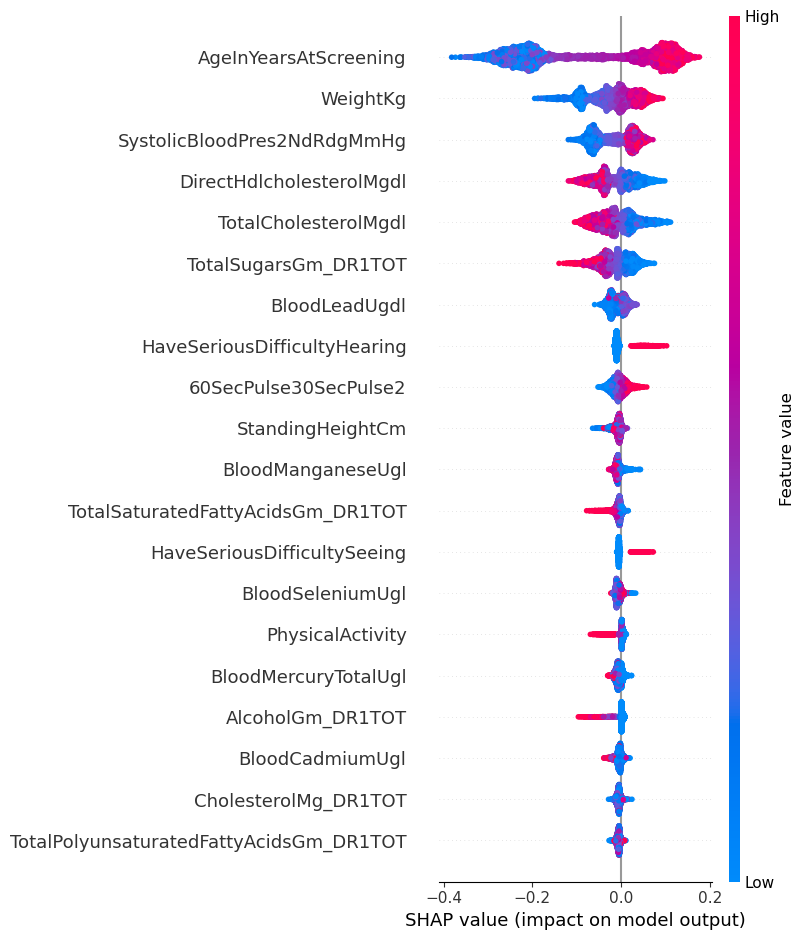

In [50]:
shap.summary_plot(shap_values[:,:,1],X_train_imp)

Patient mit hoher und niedriger Wahrscheinlichkeit für Diabetes finden:

In [133]:
np.argmax(forest_model.predict_proba(X_val)[:,1])

np.int64(268)

In [134]:
np.argmin(forest_model.predict_proba(X_val)[:,1])

np.int64(505)

In [115]:
exp = explainer(X_val)

Hohes Riskiko:

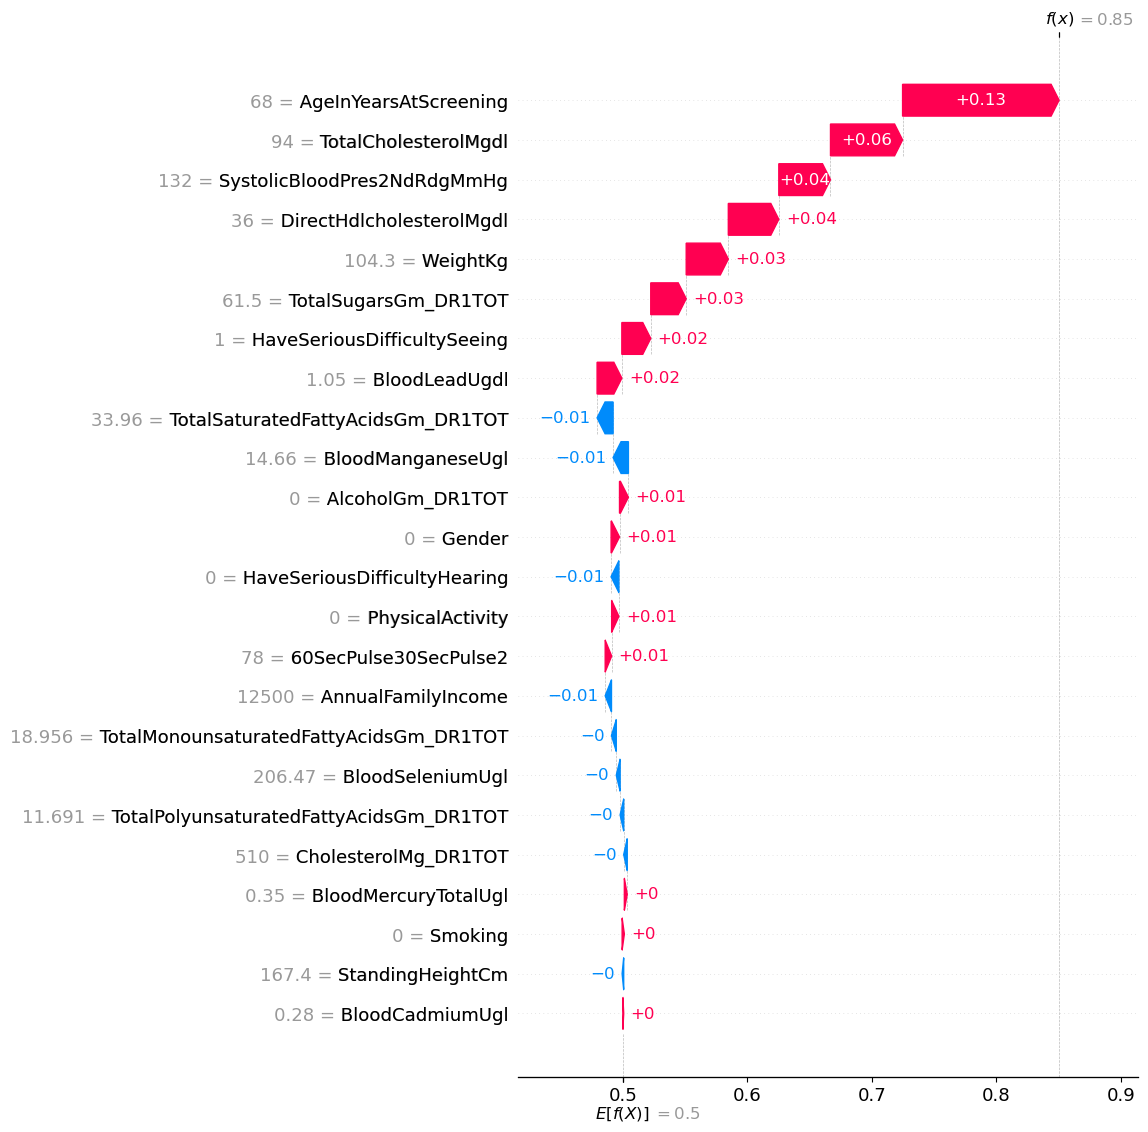

In [137]:
shap.waterfall_plot(exp[268,:,1], max_display= 24)

Niedriges Risiko:

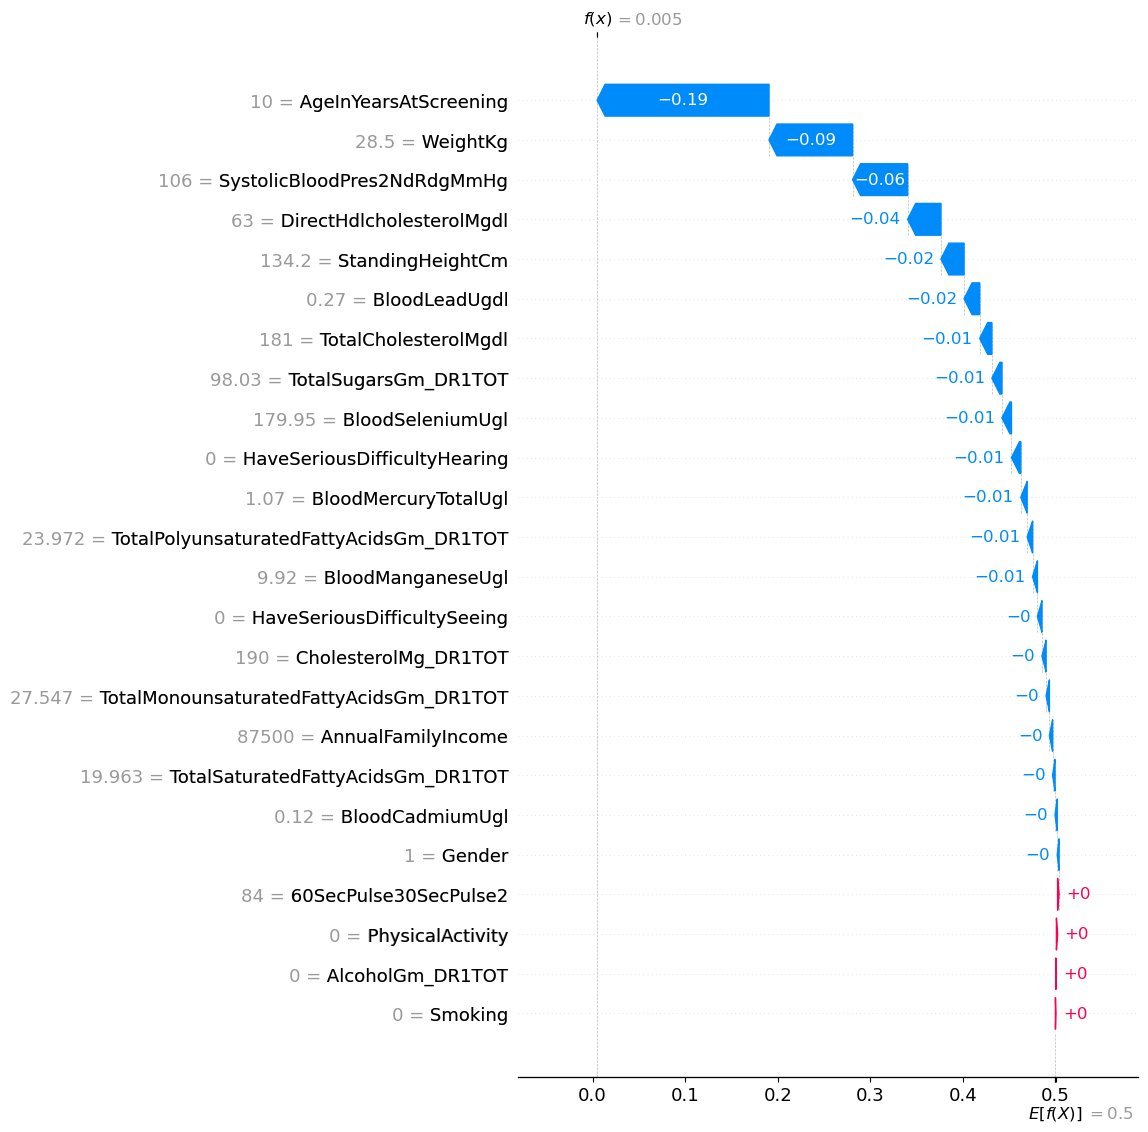

In [138]:
shap.waterfall_plot(exp[505,:,1], max_display= 24)

### Check Modell mit den 10 Wichtigsten Features

In [3]:
forest_model_limited_features = RandomForestClassifier(random_state=0, class_weight='balanced', max_depth =  17, min_samples_leaf = 10, min_samples_split= 18, n_estimators= 340)

10 Wichtigsten features:

In [34]:
top_ten = ['AgeInYearsAtScreening', 'WeightKg', 'SystolicBloodPres2NdRdgMmHg', 'DirectHdlcholesterolMgdl', 'TotalCholesterolMgdl', 'TotalSugarsGm_DR1TOT', 'BloodLeadUgdl', 'HaveSeriousDifficultyHearing', '60SecPulse30SecPulse2', 'StandingHeightCm']

In [35]:
X_train_imp_top_ten = X_train_imp.drop(columns=top_ten)
y_train_imp_top_ten = y_train_imp.drop(columns=top_ten)

X_val_top_ten = X_val.drop(columns=top_ten)
y_val_top_ten = y_val.drop(columns=top_ten)

In [36]:
forest_model_limited_features.fit(X_train_imp_top_ten, y_train_imp_top_ten)

RandomForestClassifier(class_weight='balanced', max_depth=17,
                       min_samples_leaf=10, min_samples_split=18,
                       n_estimators=340, random_state=0)

accuracy_score: 0.8355978260869565
f1_score: 0.22929936305732485
recall_score: 0.1978021978021978
precision_score: 0.2727272727272727
ROC AOC: 0.6724422863957747
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       645
           1       0.27      0.20      0.23        91

    accuracy                           0.84       736
   macro avg       0.58      0.56      0.57       736
weighted avg       0.81      0.84      0.82       736



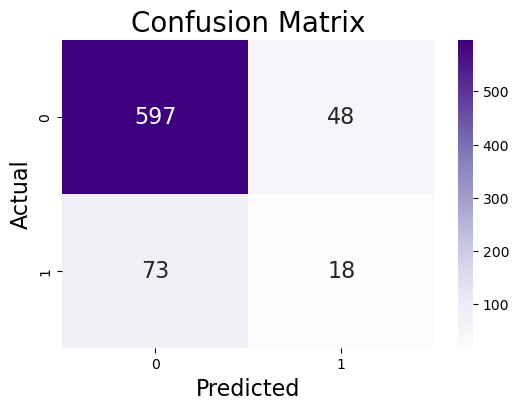

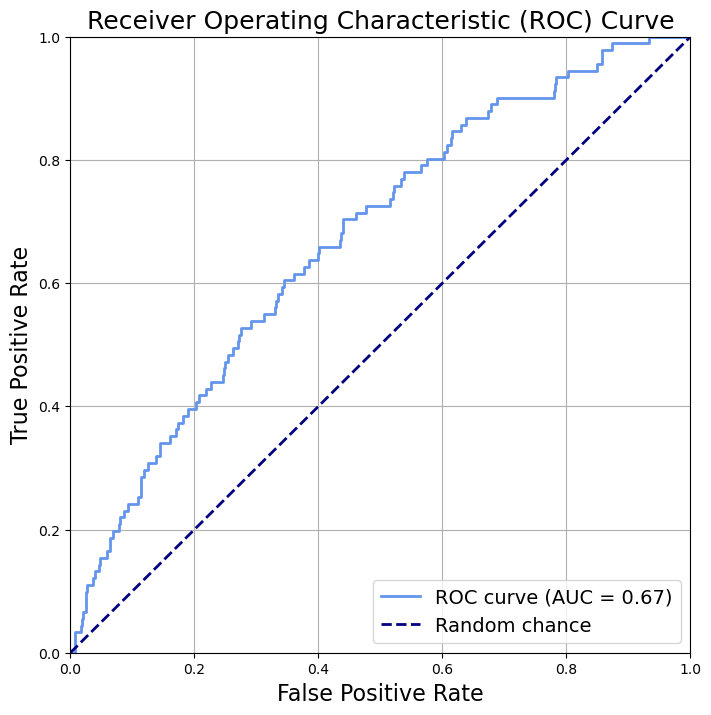

In [39]:
y_val_top_ten_preds = forest_model_limited_features.predict(X_val_top_ten)
y_val_top_ten_preds_proba = forest_model_limited_features.predict_proba(X_val_top_ten)[:, 1]
conf_matrix = sklearn.metrics.confusion_matrix(y_val_top_ten, y_val_top_ten_preds)
plot_confusion_matrix(conf_matrix)
print(f'accuracy_score: {sklearn.metrics.accuracy_score(y_val_top_ten, y_val_top_ten_preds)}')
print(f'f1_score: {sklearn.metrics.f1_score(y_val_top_ten, y_val_top_ten_preds)}')
print(f'recall_score: {sklearn.metrics.recall_score(y_val_top_ten, y_val_top_ten_preds)}')
print(f'precision_score: {sklearn.metrics.precision_score(y_val_top_ten, y_val_top_ten_preds)}')
print(f'ROC AOC: {sklearn.metrics.roc_auc_score(y_val_top_ten, y_val_top_ten_preds_proba)}')
print(sklearn.metrics.classification_report(y_val_top_ten, y_val_top_ten_preds))
plot_roc_curve(y_val_top_ten,y_val_top_ten_preds_proba, dpi=100)

Durch die Reduzierung auf die top ten wurde das Model in deutlich schlechter. 

## 8. Conclusion
- How good is your model? How well can you predict diabetes?
- Could such a model be improved further? If so, what could be done to improve the model?
- Compare your results to current research [Dinh et al., 2019](https://bmcmedinformdecismak.biomedcentral.com/articles/10.1186/s12911-019-0918-5). This is not 100% the same data, so don't worry if you cannot compare your results 1:1 with the results from the article. But their work is at least somewhat comparable. Two specific questions to answer: Is your model of comparable type to what they used in their study? And could you achieve a comparable model performance (roughly) ?

Another article (optional, only you're interested): [Vangeepuram et al., 2021](https://www.nature.com/articles/s41598-021-90406-0#Tab1) 


Das Model macht keine perfekten Vorhersagen, ob ein ungesehener Proband Diabetes hat oder nicht. In 42% der Diabetes Vorhersagen ist diese Vorhersage korrekt un es findet insgesamt 54% der gesamten Diabetes Fälle. Die ROC von 0.86 deuten auf eine relativ gute Leistung des Model hin, die weitaus besser ist als eine zufällige Entscheidung. Bei all diesen Aspekten muss der Ursprung des Datensatzes beachtet werden. Der NHANES Datensatz basiert auf Patienten aus den USA was dazu führen könnte das die Daten spezifische Aspekte anderer Bevölkerungsgruppen nicht wiederspiegeln. Dies kann dazu führen das ein Model was auf NHANES basiert dort nicht mit den gleichen Ergebnissen Einsetzbar ist. Dies kann man sich am besten bei Spalten wie **'AnnualFamilyIncome '** vorstellen.

Mehr Daten führen im Allgemeinen zu einer besseren model performance. Sowohl durch das hinzufügen von neue Features als auch Patienteneinträgen. 

Um das Model weiter zu verbessern könnten verschiedene Datenimputationsmöglichkeiten getestet werden, sowie unterschiedliche Handhabung von Spalten die aufgrund von Korrelation mit anderen spalten entfernt wurden.

### Vergleich zu Dinh et al.

Is your model of comparable type to what they used in their study?

In der Studie wird ein Ensemble Model aus logistic regression, support vector machines, random forest, und gradient boosting genutzt. Unser Random Forest bietet also ein Aspekt des Ensembles wieder. Dieser wurde wie bei uns auch in der Studie genutzt um die wichtigsten features zu identifizieren. In der Studie finden sich allerdings auch die Daten zu der Performance der einzelnen Modelle - darunter auch der Random Forest. 

And could you achieve a comparable model performance (roughly) ?

In der Studie schafft der Random Forest laut Tabelle 5 für Diabetes Typ 2 eine ROC AOC von 0.738 und für typ 1 von 0.937. Diese Beiden Ergebnisse liegen weit auseinander. Wenn es sich bei unseren Datensatz aus einer Mischung aus typ 1 und 2 handelt gibt der Random Forest aus der Studie etwas bessere Werte. Abgesehen davon ist der F1 Score deutlich höher.

## Final portfolio submission:
Your task is to address all the above-mentioned points in this notebook. Please:
- Use markdown cells to structure your notebook along the above-mentioned headers
- Use markdown cells to interpret, summarize, comment on your results, or to explain your choices.
- Normal in-line or Python code comments are fine, but better only use them to comment on minor points or code details (they can easily be overlooked during grading of the notebook).
- This notebook (and all others that will follow) are part of your portolio exam and must be **individual contributions**. It is fine to exchange ideas and discuss things. But in the end everyone is supposed to solve their own notebooks!